In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tqdm import tqdm
from scipy import stats

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Deep Evidential Regression

This notebook is based on [_Deep Evidential Regression_ by Amini et al.](https://arxiv.org/pdf/1910.02600) and [Evidential Deep Learning in PyTorch](https://github.com/teddykoker/evidential-learning-pytorch).

Let's assume we have a dataset, $\mathcal{D}$, with $N$ observations, $\mathcal{D} = \{ \mathbf{x}_i, y_i \}_{i=1}^N $.

We assume that 
$$
y_i = f_w(\mathbf{x}_i) + \epsilon_i \\
\epsilon_i \stackrel{\text{iid}}{\sim} \mathcal{N}(0, \sigma^2)
$$


### Toy Dataset

Let's create a toy dataset with 
$$
x_i \sim U[-3, 3] \\
y_i = x_i^3 + \epsilon_i \\
\epsilon_i \sim \mathcal{N}(0, 3^2)
$$



In [3]:
N = 2000

x_train = np.random.uniform(-3, 3, size=(N, 1))
y_train = x_train**3 + np.random.normal(0, 3, size=(N, 1))

Let's have a quick look at it.

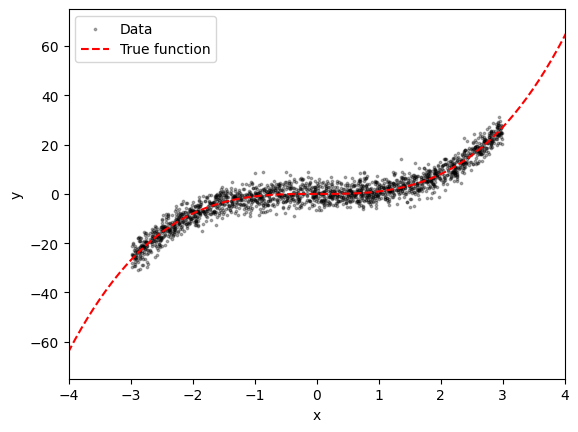

In [4]:
fig, ax = plt.subplots()
ax.scatter(x_train, y_train, s=3, alpha=0.3, c="black", label="Data")
ax.set_xlabel("x")
ax.set_ylabel("y")

x_lin = np.linspace(-5, 5, 100)
y_lin = x_lin**3
ax.plot(x_lin, y_lin, c="red", linestyle="--", label="True function")
ax.set_ylim(-75, 75)
ax.set_xlim(-4, 4)
ax.legend()

### Fitting a Neural Network with Negative Log-Likelihood

Given our assumption that $\epsilon_i \sim \mathcal{N}(0, \sigma^2)$, the likelihood of observing $y_i$ given $\mathbf{x}_i$ is:

$$
p(y_i | \mathbf{x}_i, w, \sigma^2) = \mathcal{N}(y_i | f_w(\mathbf{x}_i), \sigma^2)
$$

To fit the model, we maximize the log-likelihood (or equivalently, minimize the **negative log-likelihood**):

$$
\mathcal{L}(w, \sigma^2) = -\sum_{i=1}^{N} \log p(y_i | \mathbf{x}_i, w, \sigma^2) = \frac{N}{2}\log(2\pi\sigma^2) + \frac{1}{2\sigma^2}\sum_{i=1}^{N}(y_i - f_w(\mathbf{x}_i))^2
$$

This is the **Gaussian Negative Log-Likelihood** loss. Note that:
- We can learn both $f_w$ (the neural network) and $\sigma^2$ (the noise variance) jointly
- When $\sigma^2$ is fixed, minimizing this is equivalent to minimizing MSE
- Learning $\sigma^2$ helps the model estimate its own uncertainty

In [5]:
# Prepare data for PyTorch
x_train_tensor = torch.FloatTensor(x_train)
y_train_tensor = torch.FloatTensor(y_train)
train_dataset = torch.utils.data.TensorDataset(x_train_tensor, y_train_tensor)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)

In [6]:
class RegressionMLP(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, output_dim=1):
        super(RegressionMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [7]:
model = RegressionMLP()
v = torch.tensor([2.25], requires_grad=True)
optimizer = optim.Adam(
    [{"params": model.parameters(), "lr": 2e-3}, {"params": v, "lr": 1e-3}]
)
criterion = nn.GaussianNLLLoss()

num_epochs = 100
losses = []
log_variances = []

v.requires_grad = False

model.train()
for epoch in tqdm(range(num_epochs)):
    if epoch == 40:
        v.requires_grad = True

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        # Expand variance to match batch size
        variance = torch.exp(v).expand_as(batch_y)

        loss = criterion(outputs, batch_y, variance)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        log_variances.append(v.item())


100%|██████████| 100/100 [00:01<00:00, 73.27it/s]


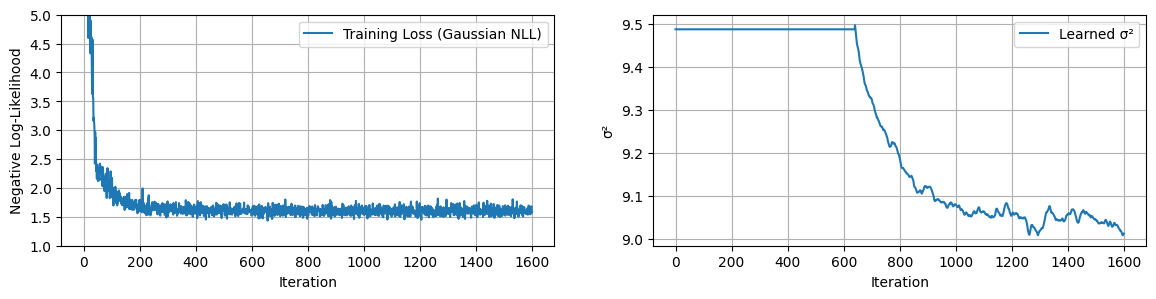

In [8]:
fig, axs = plt.subplots(ncols=2, figsize=(14, 3))
axs[0].plot(losses, label="Training Loss (Gaussian NLL)")
axs[0].set_xlabel("Iteration")
axs[0].set_ylabel("Negative Log-Likelihood")
axs[0].set_ylim(1, 5)
axs[0].grid()
axs[0].legend()

axs[1].plot(np.exp(log_variances), label="Learned σ²")
axs[1].set_xlabel("Iteration")
axs[1].set_ylabel("σ²")
axs[1].grid()
axs[1].legend()

In [9]:
residuals = []
model.eval()
with torch.no_grad():
    for batch_x, batch_y in train_loader:
        outputs = model(batch_x)
        residuals.append((outputs - batch_y).cpu().numpy())
residuals = np.concatenate(residuals, axis=0)
mse = np.mean(residuals**2)
rmse = np.sqrt(mse)

sigma_learned = torch.sqrt(torch.exp(v)).item()
print(f"Training RMSE: {rmse:.4f}")
print(f"Learned σ: {sigma_learned:.4f} (σ² = {torch.exp(v).item():.2f})")
print(f"True σ: 3.00 (σ² = 9.00)")

Training RMSE: 2.9899
Learned σ: 3.0021 (σ² = 9.01)
True σ: 3.00 (σ² = 9.00)


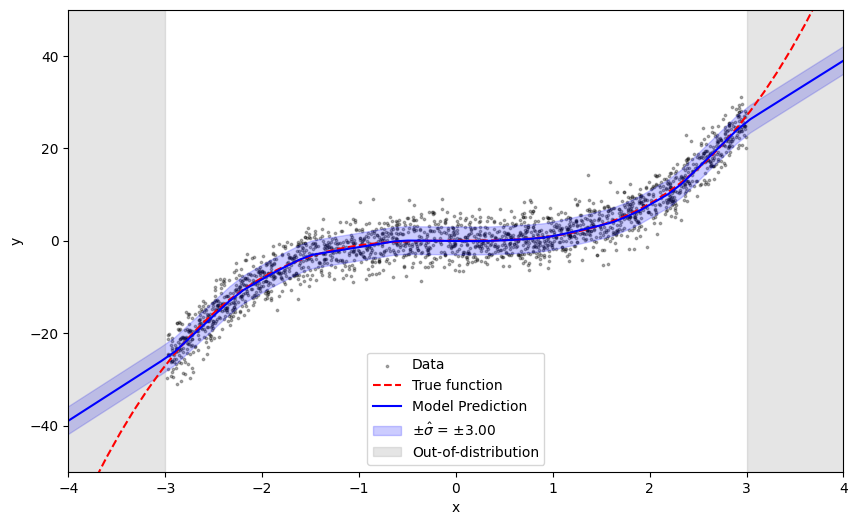

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x_train, y_train, s=3, alpha=0.3, c="black", label="Data")
ax.set_xlabel("x")
ax.set_ylabel("y")

x_lin = np.linspace(-7, 7, 100)
y_lin = x_lin**3

ax.plot(x_lin, y_lin, c="red", linestyle="--", label="True function")

y_pred = model(torch.FloatTensor(x_lin).unsqueeze(1)).detach().cpu().numpy().flatten()
ax.plot(x_lin, y_pred, c="blue", label="Model Prediction")

ax.fill_between(
    x_lin,
    y_pred - sigma_learned,
    y_pred + sigma_learned,
    color="blue",
    alpha=0.2,
    label=rf"$\pm \hat{{\sigma}}$ = $\pm${sigma_learned:.2f}",
)

ax.axvspan(-5, -3, color="gray", alpha=0.2, label="Out-of-distribution")
ax.axvspan(3, 5, color="gray", alpha=0.2)
ax.set_ylim(-50, 50)
ax.set_xlim(-4, 4)
ax.legend()

The model successfully fits the training data and learns a reasonable estimate of the noise variance ($\hat{\sigma}^2 \approx 9.06$ vs. true $\sigma^2 = 9$). 

However, this has a major drawback: The learned $\sigma^2$ only models uncertainty in the data, also known as **aleatoric uncertainty**. Uncertainty in the prediction, referred to as **epistemic uncertainty** is ignored.

This motivates **Deep Evidential Regression** that aims to _directly learn both the aleatoric uncertainty present in the data as well as the model's underlying epistemic uncertainty_.

For **Deep Evidential Regression**, we assume

$$
y_i \sim \mathcal{N}(\mu_i, \sigma_i^2) \\
\mu_i \sim \mathcal{N}(\gamma, \sigma_i^2 * v^{-1}) \\
\sigma_i^2 \sim \Gamma^{-1}(\alpha, \beta)
$$

meaning we treat $\mu$ and $\sigma^2$ as unknown and place prior distributions on them.
The goal is to estimate the posterior distribution $p(\mu, \sigma^2 | \mathcal{D})$. Due to conjuacy, this distribution will be a **Normal-Inverse-Gamma** distribution.

We can compute the prediction, aleatoric and epistemic uncertainty from this posterior distribution:
1. Prediction
$$
\mathbb{E}[\mu] = \gamma
$$

2. Aleatoric uncertainty
$$
\mathbb{E}[\sigma^2] = \frac{\beta}{\alpha - 1}
$$

3. Epistemic uncertainty
$$
\text{Var}[\mu] = \frac{\beta}{v(\alpha - 1)}
$$

The question remains how to find the parameters $\mathbf{m} = \gamma, v, \alpha, \beta$.
Simply put, we use a Neural Network to infer $m$ given an input $\mathbf{x}$.

In [48]:
class RegressionMLP(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64):
        super(RegressionMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 4)  # Output gamma, v, alpha, beta
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x) # Output gamma, v, alpha, beta

        # enforce constraints on v, alpha, beta
        gamma = x[:, 0]
        v = x[:, 1]
        alpha = x[:, 2]
        beta = x[:, 3]

        # Ensure log_variance is positive 
        v = F.softplus(v)
        alpha = F.softplus(alpha) + 1 + 1e-6  # Ensure alpha > 1 for valid IG distribution
        beta = F.softplus(beta) + 1e-6  # Ensure beta > 0 for valid IG distribution

        # Return constrained outputs
        return torch.stack([gamma, v, alpha, beta], dim=1)

In [49]:
def compute_prediction(gamma, _v, _alpha, _beta):
    return gamma

def compute_aleatoric_uncertainty(_gamma, _v, alpha, beta):
    return beta / (alpha - 1)

def compute_epistemic_uncertainty(_gamma, v, alpha, beta):
    return beta / (v * (alpha - 1))

def compute_total_uncertainty(_gamma, v, alpha, beta):
    return compute_aleatoric_uncertainty(_gamma, v, alpha, beta) + compute_epistemic_uncertainty(_gamma, v, alpha, beta)

In [50]:
def nig_nll(gamma, v, alpha, beta, y):
    two_beta_lambda = 2 * beta * (1 + v)
    t1 = 0.5 * (torch.pi / v).log()
    t2 = alpha * two_beta_lambda.log()
    t3 = (alpha + 0.5) * (v * (y - gamma) ** 2 + two_beta_lambda).log()
    t4 = alpha.lgamma()
    t5 = (alpha + 0.5).lgamma()
    nll = t1 - t2 + t3 + t4 - t5
    return nll.mean()

def nig_reg(gamma, v, alpha, _beta, y):
    reg = (y - gamma).abs() * (2 * v + alpha)
    return reg.mean()


In [107]:
model = RegressionMLP()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
reg_lambda = 0.01

nll_losses = []
reg_losses = []
num_epochs = 300
model.train()

for epoch in tqdm(range(num_epochs)):
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        gamma, v, alpha, beta = outputs[:, 0], outputs[:, 1], outputs[:, 2], outputs[:, 3]
        nll_loss = nig_nll(gamma, v, alpha, beta, batch_y.squeeze())
        reg_loss = nig_reg(gamma, v, alpha, beta, batch_y.squeeze())
        loss = nll_loss + reg_lambda * reg_loss
        loss.backward()
        optimizer.step()
        nll_losses.append(nll_loss.item())
        reg_losses.append(reg_loss.item())

100%|██████████| 300/300 [00:05<00:00, 54.62it/s]


(3.0, 8.0)

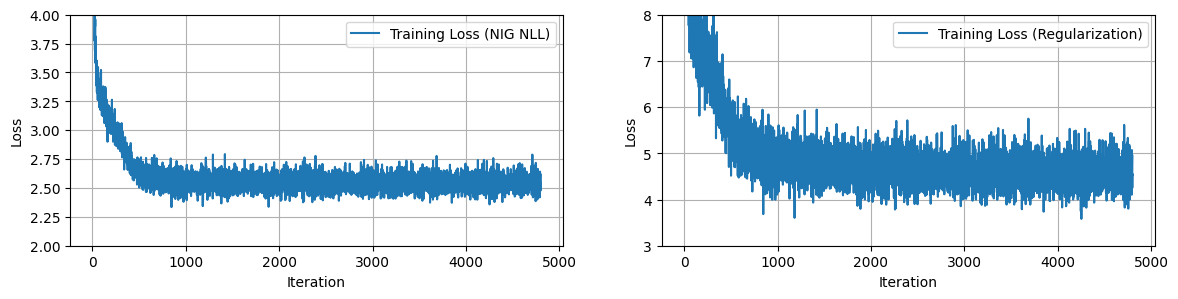

In [108]:
fig, axs = plt.subplots(ncols=2, figsize=(14, 3))
axs[0].plot(nll_losses, label="Training Loss (NIG NLL)")
axs[0].set_xlabel("Iteration")
axs[0].set_ylabel("Loss")
axs[0].grid()
axs[0].legend()
axs[0].set_ylim(2, 4)

axs[1].plot(reg_losses, label="Training Loss (Regularization)")
axs[1].set_xlabel("Iteration")
axs[1].set_ylabel("Loss")
axs[1].grid()
axs[1].legend()
axs[1].set_ylim(3, 8)

In [109]:
residuals = []
model.eval()
with torch.no_grad():
    for batch_x, batch_y in train_loader:
        outputs = model(batch_x)
        predictions = compute_prediction(outputs[:, 0], outputs[:, 1], outputs[:, 2], outputs[:, 3])
        residuals.append((predictions - batch_y[:, 0]).cpu().numpy())
residuals = np.concatenate(residuals, axis=0)
mse = np.mean(residuals**2)
rmse = np.sqrt(mse)

print(f"Training RMSE: {rmse:.4f}")

Training RMSE: 3.0092


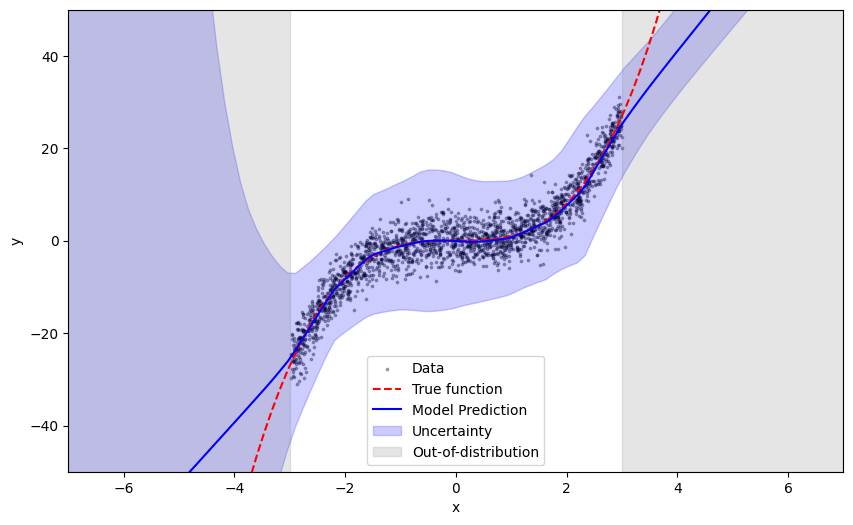

In [110]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x_train, y_train, s=3, alpha=0.3, c="black", label="Data")
ax.set_xlabel("x")
ax.set_ylabel("y")

x_lin = np.linspace(-7, 7, 100)
y_lin = x_lin**3

ax.plot(x_lin, y_lin, c="red", linestyle="--", label="True function")

outputs = model(torch.FloatTensor(x_lin).unsqueeze(1)).detach().cpu().numpy()
gamma, v, alpha, beta = outputs[:, 0], outputs[:, 1], outputs[:, 2], outputs[:, 3]

y_pred = compute_prediction(gamma, v, alpha, beta)
uncertainty = compute_total_uncertainty(gamma, v, alpha, beta)

ax.plot(x_lin, y_pred, c="blue", label="Model Prediction")

ax.fill_between(
    x_lin,
    y_pred - uncertainty,
    y_pred + uncertainty,
    color="blue",
    alpha=0.2,
    label="Uncertainty",
)

ax.axvspan(-7, -3, color="gray", alpha=0.2, label="Out-of-distribution")
ax.axvspan(3, 7, color="gray", alpha=0.2)
ax.set_ylim(-50, 50)
ax.set_xlim(-7, 7)
ax.legend()